# Marta Negri 75169
# Luca Davì 75214
## Task1

You will start by performing
object detection and evaluate it using three modern detectors: YOLOv11 [2], DETR [1], and
RT-DETR [7]. You should use YOLOv11 from Ultralytics, DETR from HuggingFace DETR and
RT-DETR from HuggingFace RT-DETR.
Your goal is to analyze and discuss their individual performance on the first 1000 samples
of the PASCAL VOC 2007 validation set

Run inference with each of the three models (YOLOv11, DETR, RF-DETR) on the selected
dataset subset: the first 1000 samples of PASCAL VOC validation set.

In [25]:
!pip install datasets transformers timm wandb matplotlib albumentations
!pip install pycocotools
!pip install torchmetrics
!pip install ultralytics
!pip install supervision
!pip install roboflow

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [26]:
# Importing the required libraries
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import torch
from ultralytics import YOLO
from transformers import pipeline

from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.datasets import VOCDetection


In [27]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

In [28]:
# Model instantiation

yolo_model = YOLO('yolo11m.pt').to(device)
detr_model = pipeline('object-detection', model='facebook/detr-resnet-50',device=device)
rt_detr_model = pipeline('object-detection', model='PekingU/rtdetr_r50vd',device=device)

print(f'Models are on device: \nYOLO: {yolo_model.device}\nDETR device: {detr_model.device}\nRT-DETR device: {rt_detr_model.device}')


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps
Device set to use mps


Models are on device: 
YOLO: mps:0
DETR device: mps
RT-DETR device: mps


In [30]:

dataset = VOCDetection(root='data/', year='2007', image_set='val', download=False)
subset_size = 1000
subset = torch.utils.data.Subset(dataset, list(range(subset_size)))

VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
VOC_CLASS_TO_ID = {cls_name: idx+1 for idx, cls_name in enumerate(VOC_CLASSES)}

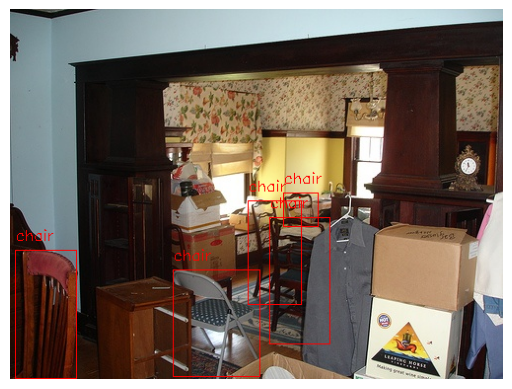

In [31]:
#Prepare in TorchMetrics format

targets_list = []
for img, target in subset:
    objs = target['annotation']['object']
    if not isinstance(objs, list):
        objs = [objs]
    boxes = []
    labels = []
    for obj in objs:
        b = obj['bndbox']
        boxes.append([float(b['xmin']), float(b['ymin']), float(b['xmax']), float(b['ymax'])])
        labels.append(VOC_CLASS_TO_ID[obj['name']])
    targets_list.append({
        'boxes': torch.tensor(boxes, dtype=torch.float32),
        'labels': torch.tensor(labels, dtype=torch.int64)
    })

# Display first image and its targets to verify: draw bounding boxes
img, target = subset[0]
boxes = target['annotation']['object']
if not isinstance(boxes, list):
    boxes = [boxes]
img_cv = np.array(img)
for box in boxes:
    b = box['bndbox']
    xmin, ymin, xmax, ymax = int(b['xmin']), int(b['ymin']), int(b['xmax']), int(b['ymax'])
    cv2.rectangle(img_cv, (xmin, ymin), (xmax, ymax), (255, 0, 0), 1)
    # Put class label
    class_name = box['name']
    cv2.putText(img_cv, class_name, (xmin, ymin-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
plt.imshow(img_cv)
plt.axis('off')
plt.show()

In [24]:
#convert predictions to VOC format

def convert_yolo_predictions(yolo_results, coco_classes, voc_map):
    yolo_boxes = torch.tensor(yolo_results.boxes.xyxy, dtype=torch.float32)
    yolo_scores = torch.tensor(yolo_results.boxes.conf, dtype=torch.float32)

    # Convert YOLO class indices → names → VOC ids
    labels_list = []
    for label_idx in yolo_results.boxes.cls:
        name = coco_classes[label_idx.item()]
        label_id = voc_map.get(name, 0)
        labels_list.append(label_id)

    yolo_labels = torch.tensor(labels_list, dtype=torch.int64)

    return {
        "boxes": yolo_boxes,
        "scores": yolo_scores,
        "labels": yolo_labels,
    }

def convert_detr_predictions(detr_results, voc_map, confidence=0.1):
    # Filter by confidence
    detr_results = [r for r in detr_results if r["score"] >= confidence]

    if len(detr_results) == 0:
        return None

    boxes_list = []
    scores_list = []
    labels_list = []

    for r in detr_results:
        box = r["box"]

        # Convert to xyxy
        if isinstance(box, dict):
            boxes_list.append([box["xmin"], box["ymin"], box["xmax"], box["ymax"]])
        else:
            x, y, w, h = box
            boxes_list.append([x, y, x + w, y + h])

        scores_list.append(r["score"])
        label_id = voc_map.get(r["label"], 0)
        labels_list.append(label_id)

    return {
        "boxes": torch.tensor(boxes_list, dtype=torch.float32),
        "scores": torch.tensor(scores_list, dtype=torch.float32),
        "labels": torch.tensor(labels_list, dtype=torch.int64),
    }

In [ ]:
#evaluation loop

COCO_CLASSES = yolo_model.names

def evaluate_sample(img, target, yolo_model, detr_pipeline, rt_detr_pipeline, coco_classes, voc_map,
                    metric_yolo, metric_detr, metric_rt_detr, confidence=0.1):
    img_np = np.array(img)

    # --- YOLO ---
    yolo_raw = yolo_model(img_np, conf=confidence, verbose=False,device=device)[0]
    yolo_preds = convert_yolo_predictions(yolo_raw, coco_classes, voc_map)
    metric_yolo.update([yolo_preds], [target])

    # --- DETR ---
    detr_raw = detr_pipeline(img)
    detr_preds = convert_detr_predictions(detr_raw, voc_map, confidence=confidence)
    if detr_preds is not None:
        metric_detr.update([detr_preds], [target])
    rt_detr_raw = rt_detr_pipeline(img)
    rt_detr_preds = convert_detr_predictions(rt_detr_raw, voc_map, confidence=confidence)
    if rt_detr_preds is not None:
        metric_rt_detr.update([rt_detr_preds], [target])

def evaluate_models(yolo_model, detr_pipeline, rt_detr_pipeline, subset, targets_list, coco_classes, voc_map, confidence=0.1):
    # Load models


    # Metrics
    metric_yolo = MeanAveragePrecision()
    metric_detr = MeanAveragePrecision()
    metric_rt_detr = MeanAveragePrecision()

    # Loop through samples
    for sample, target in zip(subset, targets_list):
        img = sample[0]
        evaluate_sample(img, target, yolo_model, detr_pipeline, rt_detr_pipeline,
                        coco_classes, voc_map, metric_yolo, metric_detr, metric_rt_detr, confidence=confidence)

    # Compute
    return metric_yolo.compute(), metric_detr.compute(), metric_rt_detr.compute()


In [10]:
#evaluate on first 1000 samples
yolo_map, detr_map, rt_detr_map = evaluate_models(
    yolo_model, detr_model, rt_detr_model,
    subset, targets_list,
    COCO_CLASSES, VOC_CLASS_TO_ID,
    confidence=0.1
)
print("YOLO mAP:", yolo_map)
print("DETR mAP:", detr_map)
print("RT-DETR mAP:", rt_detr_map)

YOLO mAP: {'map': tensor(0.4663), 'map_50': tensor(0.5984), 'map_75': tensor(0.5058), 'map_small': tensor(0.2350), 'map_medium': tensor(0.3858), 'map_large': tensor(0.5549), 'mar_1': tensor(0.3240), 'mar_10': tensor(0.5002), 'mar_100': tensor(0.5097), 'mar_small': tensor(0.3141), 'mar_medium': tensor(0.4575), 'mar_large': tensor(0.5839), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], dtype=torch.int32)}
DETR mAP: {'map': tensor(0.4192), 'map_50': tensor(0.5798), 'map_75': tensor(0.4468), 'map_small': tensor(0.2033), 'map_medium': tensor(0.3376), 'map_large': tensor(0.5292), 'mar_1': tensor(0.3101), 'mar_10': tensor(0.4687), 'mar_100': tensor(0.4792), 'mar_small': tensor(0.2914), 'mar_medium': tensor(0.3959), 'mar_large': tensor(0.5693), 'map_per_class': tensor(-1.), 'mar_100_per_class': tensor(-1.), 'classes': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 1

# TODO:
 run with different confidence param (task 1.2), compare results(task 1.3)